In [3]:
import pandas as pd, numpy as np


In [4]:
df = pd.read_csv('/content/heart_disease_combined.csv')

In [5]:
# chol=0 and trestbps=0 mean "not recorded", not a real measurement
for col in ['chol', 'trestbps']:
    df.loc[df[col] == 0, col] = np.nan


In [6]:
df = df.drop_duplicates().reset_index(drop=True)   # 920 -> 918
df['oldpeak'] = df['oldpeak'].clip(lower=0)        # ST depression can't be negative


In [7]:
# NO dropna. NO get_dummies on source. NO fillna here.
print(df.shape)
df.groupby('source')['target'].agg(['count','mean']).round(3)


(918, 15)


,count,mean
source,,
cleveland,303,0.459
hungarian,293,0.362
switzerland,123,0.935
va,199,0.744


In [14]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

BEDSIDE = ['age','sex','cp','trestbps','chol','fbs','restecg']
STRESS  = BEDSIDE + ['thalach','exang','oldpeak','slope']
IMAGING = STRESS  + ['thal','ca']
TIERS   = {'bedside': BEDSIDE, 'stress': STRESS, 'imaging': IMAGING}

NUM = ['age','trestbps','chol','thalach','oldpeak']
CAT = ['sex','cp','fbs','restecg','exang','slope','thal','ca']

def make_model(features):
    num = [f for f in features if f in NUM]
    cat = [f for f in features if f in CAT]
    return Pipeline([
        ('prep', ColumnTransformer([
            ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                              ('sc',  StandardScaler())]), num),
            ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                              ('oh',  OneHotEncoder(handle_unknown='ignore',
                                                    sparse_output=False))]), cat),
        ])),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced')),
    ])

rows = []
for tier, feats in TIERS.items():
    for site in ['cleveland','hungarian','switzerland','va']:
        te, tr = df[df.source == site], df[df.source != site]
        model = make_model(feats).fit(tr[feats], tr['target'])
        prob  = model.predict_proba(te[feats])[:, 1]
        rows.append({'tier': tier, 'held_out': site, 'n': len(te),
                     'prevalence': round(te['target'].mean(), 3),
                     'AUROC': round(roc_auc_score(te['target'], prob), 3)})

res = pd.DataFrame(rows)
print(res.pivot(index='held_out', columns='tier', values='AUROC'))


tier         bedside  imaging  stress
held_out                             
cleveland      0.817    0.835   0.861
hungarian      0.848    0.897   0.895
switzerland    0.768    0.760   0.754
va             0.705    0.725   0.748


In [15]:
from sklearn.metrics import brier_score_loss, confusion_matrix, roc_curve

TARGET_SENS = 0.90   # we want to catch 90% of sick patients

def threshold_for_sensitivity(y, p, target):
    fpr, tpr, thr = roc_curve(y, p)
    ok = np.where(tpr >= target)[0]
    return thr[ok[0]] if len(ok) else 0.5

rows = []
for tier, feats in TIERS.items():
    for site in ['cleveland','hungarian','switzerland','va']:
        te, tr = df[df.source == site], df[df.source != site]
        m = make_model(feats).fit(tr[feats], tr['target'])

        # threshold chosen on TRAINING data only - never on the test site
        thr = threshold_for_sensitivity(tr['target'],
                                        m.predict_proba(tr[feats])[:,1], TARGET_SENS)

        p    = m.predict_proba(te[feats])[:,1]
        yhat = (p >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(te['target'], yhat, labels=[0,1]).ravel()

        rows.append({'tier':tier, 'site':site, 'n':len(te), 'prev':round(te.target.mean(),2),
                     'AUROC':round(roc_auc_score(te.target, p),3),
                     'sens':round(tp/(tp+fn),3), 'spec':round(tn/(tn+fp),3),
                     'PPV':round(tp/(tp+fp),3),  'NPV':round(tn/(tn+fn),3),
                     'missed':int(fn), 'Brier':round(brier_score_loss(te.target,p),3)})

r = pd.DataFrame(rows)
for t in ['bedside','stress','imaging']:
    print(f"\n=== {t.upper()} ===")
    print(r[r.tier==t].drop(columns='tier').to_string(index=False))



=== BEDSIDE ===
       site   n  prev  AUROC  sens  spec   PPV   NPV  missed  Brier
  cleveland 303  0.46  0.817 0.863 0.616 0.656 0.842      19  0.172
  hungarian 293  0.36  0.848 0.792 0.775 0.667 0.868      22  0.148
switzerland 123  0.93  0.768 0.922 0.500 0.964 0.308       9  0.146
         va 199  0.74  0.705 0.980 0.275 0.797 0.824       3  0.176

=== STRESS ===
       site   n  prev  AUROC  sens  spec   PPV   NPV  missed  Brier
  cleveland 303  0.46  0.861 0.842 0.689 0.696 0.837      22  0.150
  hungarian 293  0.36  0.895 0.915 0.743 0.669 0.939       9  0.128
switzerland 123  0.93  0.754 0.843 0.625 0.970 0.217      18  0.184
         va 199  0.74  0.748 0.905 0.333 0.798 0.548      14  0.165

=== IMAGING ===
       site   n  prev  AUROC  sens  spec   PPV   NPV  missed  Brier
  cleveland 303  0.46  0.835 0.892 0.524 0.614 0.851      15  0.177
  hungarian 293  0.36  0.897 0.887 0.743 0.662 0.921      12  0.123
switzerland 123  0.93  0.760 0.843 0.500 0.960 0.182      18  0.18

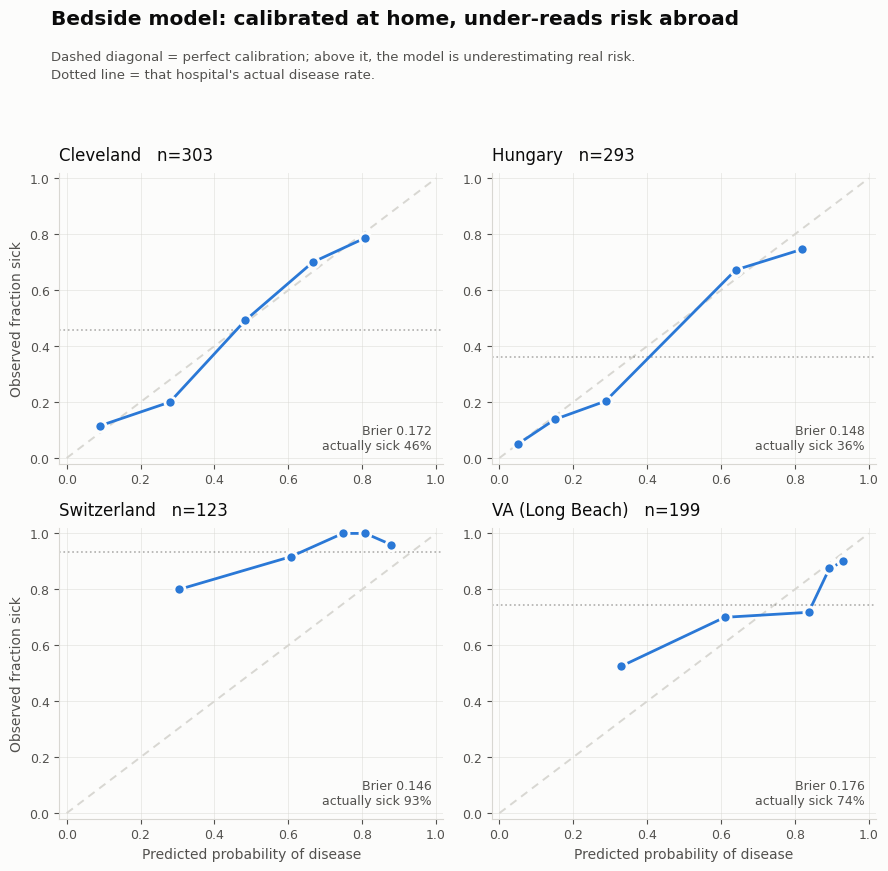

In [16]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

BLUE, INK, MUTED, GRID, SURFACE = '#2a78d6', '#0b0b0b', '#52514e', '#d8d7d2', '#fcfcfb'
SITES = [('cleveland','Cleveland'), ('hungarian','Hungary'),
         ('switzerland','Switzerland'), ('va','VA (Long Beach)')]

fig, axes = plt.subplots(2, 2, figsize=(9, 8.8), facecolor=SURFACE)
for ax, (site, label) in zip(axes.ravel(), SITES):
    te, tr = df[df.source == site], df[df.source != site]
    m = make_model(BEDSIDE).fit(tr[BEDSIDE], tr['target'])
    p = m.predict_proba(te[BEDSIDE])[:, 1]
    frac, mean = calibration_curve(te['target'], p, n_bins=5, strategy='quantile')

    ax.set_facecolor(SURFACE)
    ax.plot([0,1], [0,1], ls=(0,(4,3)), lw=1.4, color=GRID, zorder=1)          # perfect
    ax.axhline(te['target'].mean(), lw=1.2, color=MUTED, alpha=.45, ls=':', zorder=2)
    ax.plot(mean, frac, '-o', lw=2, ms=8, color=BLUE, mec=SURFACE, mew=2, zorder=3)

    ax.set_xlim(-.02,1.02); ax.set_ylim(-.02,1.02)
    ax.set_title(f"{label}   n={len(te)}", fontsize=12, color=INK, loc='left', pad=9)
    ax.text(.97, .04, f"Brier {brier_score_loss(te['target'],p):.3f}\n"
                      f"actually sick {te['target'].mean():.0%}",
            fontsize=9, color=MUTED, va='bottom', ha='right', transform=ax.transAxes)
    ax.grid(True, lw=.6, color=GRID, alpha=.55); ax.set_axisbelow(True)
    for s in ('top','right'): ax.spines[s].set_visible(False)
    for s in ('left','bottom'): ax.spines[s].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)

for ax in axes[1]:    ax.set_xlabel('Predicted probability of disease', fontsize=10, color=MUTED)
for ax in axes[:,0]:  ax.set_ylabel('Observed fraction sick', fontsize=10, color=MUTED)

fig.suptitle('Bedside model: calibrated at home, under-reads risk abroad',
             x=.062, y=.985, ha='left', fontsize=14.5, color=INK, fontweight='bold')
fig.text(.062, .938, "Dashed diagonal = perfect calibration; above it, the model is "
                     "underestimating real risk.\nDotted line = that hospital's actual disease rate.",
         ha='left', va='top', fontsize=9.5, color=MUTED, linespacing=1.5)
fig.tight_layout(rect=[0,0,1,.885])
plt.show()


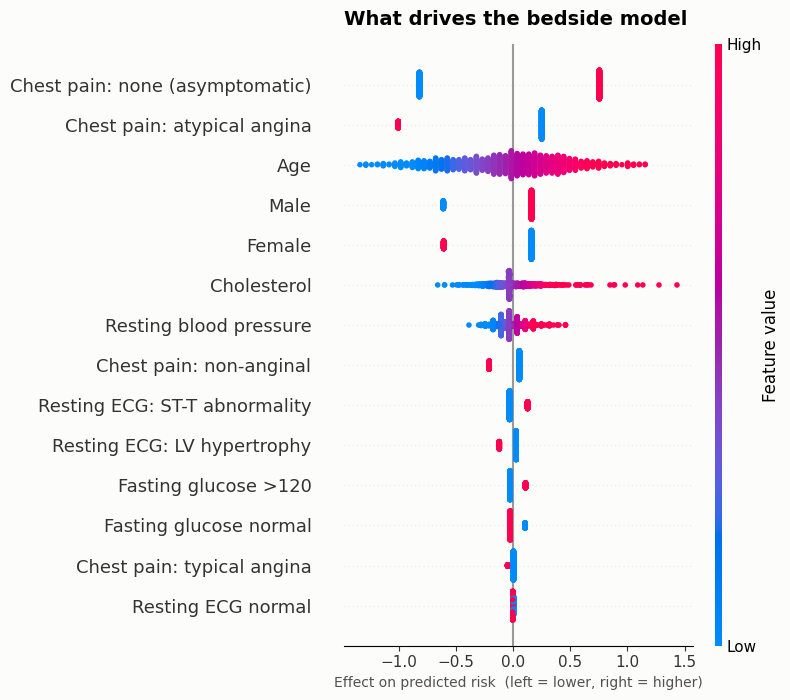

  Chest pain: none (asymptomatic)      +1.573  increases risk
  Chest pain: atypical angina          -1.255  decreases risk
  Male                                 +0.771  increases risk
  Female                               -0.767  decreases risk
  Age                                  +0.480  increases risk
  Chest pain: non-anginal              -0.263  decreases risk
  Cholesterol                          +0.209  increases risk
  Resting ECG: ST-T abnormality        +0.158  increases risk
  Resting ECG: LV hypertrophy          -0.148  decreases risk
  Fasting glucose >120                 +0.135  increases risk
  Fasting glucose normal               -0.131  decreases risk
  Resting blood pressure               +0.126  increases risk
  Chest pain: typical angina           -0.051  decreases risk
  Resting ECG normal                   -0.005  decreases risk


In [17]:
import shap

PRETTY = {
    'sex_0.0':'Female', 'sex_1.0':'Male',
    'cp_1.0':'Chest pain: typical angina',  'cp_2.0':'Chest pain: atypical angina',
    'cp_3.0':'Chest pain: non-anginal',     'cp_4.0':'Chest pain: none (asymptomatic)',
    'fbs_0.0':'Fasting glucose normal',     'fbs_1.0':'Fasting glucose >120',
    'restecg_0.0':'Resting ECG normal',     'restecg_1.0':'Resting ECG: ST-T abnormality',
    'restecg_2.0':'Resting ECG: LV hypertrophy',
    'age':'Age', 'trestbps':'Resting blood pressure', 'chol':'Cholesterol',
}

model = make_model(BEDSIDE).fit(df[BEDSIDE], df['target'])
prep  = model.named_steps['prep']
X     = prep.transform(df[BEDSIDE])
names = [PRETTY.get(n.split('__')[-1], n.split('__')[-1]) for n in prep.get_feature_names_out()]

sv = shap.LinearExplainer(model.named_steps['clf'], X)(X)
sv.feature_names = names

plt.figure(figsize=(9, 5.5))
shap.plots.beeswarm(sv, max_display=14, show=False)
plt.gcf().set_facecolor('#fcfcfb'); plt.gca().set_facecolor('#fcfcfb')
plt.gca().set_xlabel('Effect on predicted risk  (left = lower, right = higher)',
                     fontsize=10, color='#52514e')
plt.title('What drives the bedside model', loc='left', fontsize=14, fontweight='bold', pad=14)
plt.tight_layout(); plt.show()

# plain-language direction of each effect
coef = model.named_steps['clf'].coef_[0]
for i in np.argsort(-np.abs(coef)):
    print(f"  {names[i]:36s} {coef[i]:+.3f}  {'increases' if coef[i]>0 else 'decreases'} risk")
